## **Read data and Imports**

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    tf.config.set_logical_device_configuration(
        gpus[0],
        [tf.config.LogicalDeviceConfiguration(memory_limit=3000)]
    )

In [ ]:
import pandas as pd
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from skrebate import ReliefF
import missingno as msno
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import os
import random
import cv2 as cv2
import sklearn
from sklearn.feature_selection import (
    mutual_info_regression,  # Information Gain
    chi2,                    # Chi-square Test
    f_classif,               # ANOVA (F-test)
    SelectKBest,             # Select top k features
    VarianceThreshold        # Variance Threshold
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler

2026-04-20 20:43:49.620167: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-20 20:43:49.620257: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-20 20:43:49.675861: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-20 20:43:49.788853: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-20 20:43:51.282899: W tensorflow/compiler/tf2

In [2]:
data = pd.read_csv("../../Data/dataset_split/train/train.csv")

## **Preprocessing**

**Feature Engineering**

In [27]:
data2 = data.copy()
# data2.drop(columns=['image_id','patient_id'],inplace = True)

In [ ]:
data2.drop(columns=['nationality'],inplace=True)
data2.drop(columns=['insuline'],inplace=True)
data2.drop(columns=['focus', 'Illuminaton', 'image_field', 'artifacts'],inplace=True)
data2.drop(columns=['diabetes_time_y','comorbidities'],inplace=True)
data2.drop(columns=['camera'],inplace=True)
data2.drop(columns=['quality'],inplace=True)
data2.drop(columns=['other'],inplace=True)
# high correlated with X feature
data2.drop(columns=['DR_SDRG'],inplace=True)

In [29]:
data2['exam_eye'] = data2['exam_eye'].map({1: 0, 2: 1})

data2['vessels'] = data2['vessels'].map({1: 0, 2: 1})

data2['macula'] = data2['macula'].map({1: 0, 2: 1})

data2['patient_sex'] = data2['patient_sex'].map({1: 0, 2: 1})

data2['diabetes'] = data2['diabetes'].map({'yes': 1, 'No': 0})

data2['optic_disc'] = data2['optic_disc'].map({1: 0, 2: 1})

In [30]:
count = 1
for col in data2.columns:
    print(f"{count}. Unique Values for [ {col} ] is : ",data2[col].unique(),'\n')
    count+=1

1. Unique Values for [ image_id ] is :  ['img00001' 'img00002' 'img00003' ... 'img16262' 'img16265' 'img16266'] 

2. Unique Values for [ patient_id ] is :  [   1    2    3 ... 8520 8522 8524] 

3. Unique Values for [ patient_age ] is :  [48. 18. 22. 23. 14. 20. 28. 37. 21. 16. 24. 26. 19. 17. 13. 27. 39. 25.
 30. 15. 29. 57. 44. 38. 47. 42. 10. 59. 32. 66. 82. 87. 80. 41. 76. 71.
 73. 83. 45. 61. 55. 75. 81. 72. 64. 46. 74. 65. 31. 33. 53. 50. 51. 49.
 63. 62. 52. 70. 79. 60. 78. 54. 56. 77. 58. 85. 86. 84. 69. 11. 68. nan
  9. 91. 36. 90. 67. 88.  7. 35. 40. 43. 89. 34. 12.  8. 95. 97.  6. 93.
 94.  5. 92.] 

4. Unique Values for [ patient_sex ] is :  [0 1] 

5. Unique Values for [ exam_eye ] is :  [0 1] 

6. Unique Values for [ diabetes ] is :  [1 0] 

7. Unique Values for [ optic_disc ] is :  [0 1] 

8. Unique Values for [ vessels ] is :  [0 1] 

9. Unique Values for [ macula ] is :  [0 1] 

10. Unique Values for [ DR_ICDR ] is :  [0 1 2 4 3] 

11. Unique Values for [ diabetic_retin

In [31]:
def show_missing(data2):
    """
    Visualizes and reports missing values in a Pandas data2Frame.

    Parameters:
    - data2 (data2Frame): The input Pandas data2Frame to check for missing values.

    Returns:
    None

    This function performs the following tasks:
    1. Displays a missing data2 matrix plot to visualize the location of missing values in the data2Frame.
    2. Prints the percentage of missing values in each column with missing data2.
    3. Creates a bar plot to visualize the percentage of missing values in each column.

    Example usage:
    show_missing(data2)
    """
    
    # Visualize the percentage of missing data2 using a bar plot
    msno.matrix(data2)
    
    
    # Print the percentage of missing values in the columns with missing
    features_with_nan = [features for features in data2.columns if data2[features].isnull().sum()>=1]
    print(f'{len(features_with_nan)} columns with missing values detected:')

    for features in features_with_nan:
        print(features , np.round(data2[features].isnull().mean(),4) * 100 , '% missing values')

    
    # Create a bar plot to visualize missing values
    # Calculate the percentage of missing data2 in each column
    missing_percentage = data2.isnull().mean() * 100
    missing_percentage
    
    plt.figure(figsize=(10, 6))
    missing_percentage.plot(kind='bar', color='skyblue')
    plt.title('Percentage of Missing Values per Column')
    plt.xlabel('Columns')
    plt.ylabel('Percentage Missing')
    plt.xticks(rotation=90)
    plt.tight_layout()
    
    plt.show()

In [32]:
data2['patient_age_missing'] = data2['patient_age'].isnull().astype(int)
data2['patient_age'] = data2['patient_age'].fillna(data2['patient_age'].median())

0 columns with missing values detected:


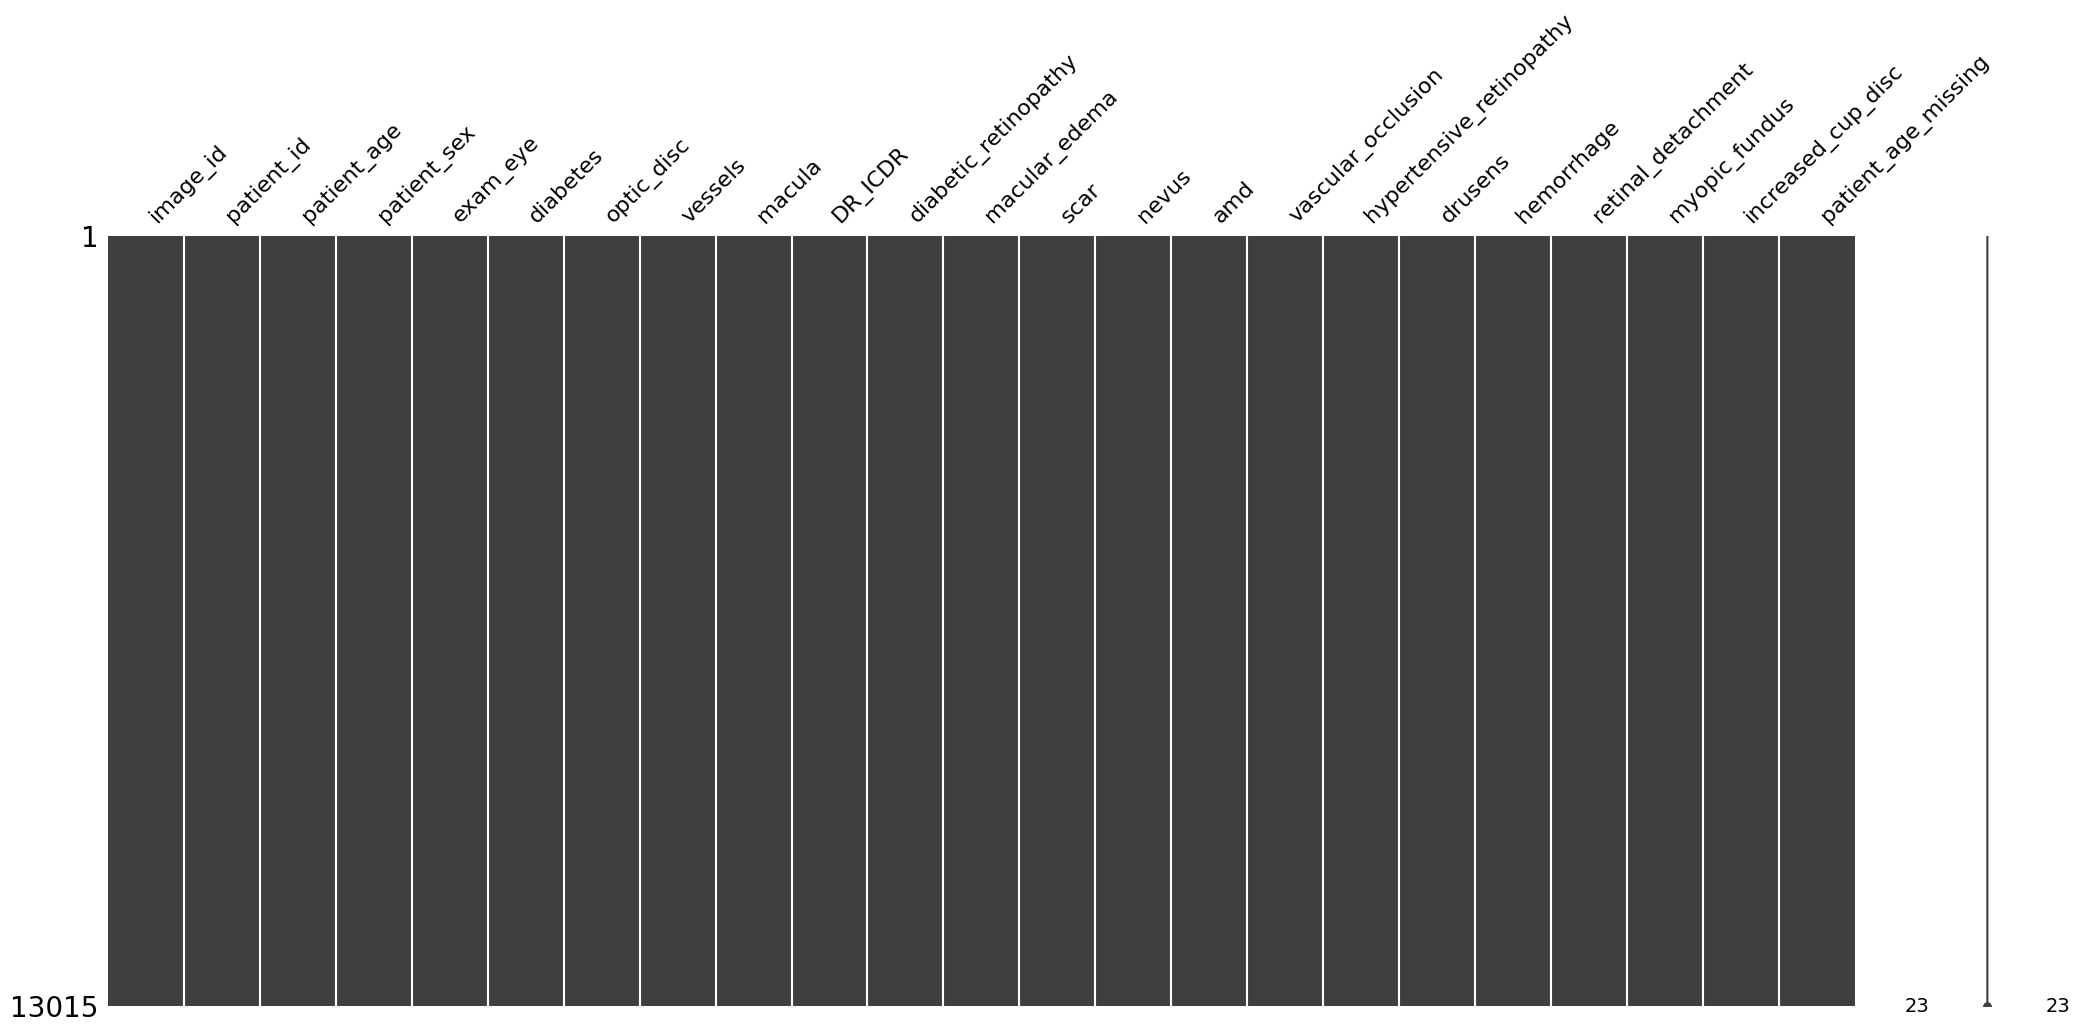

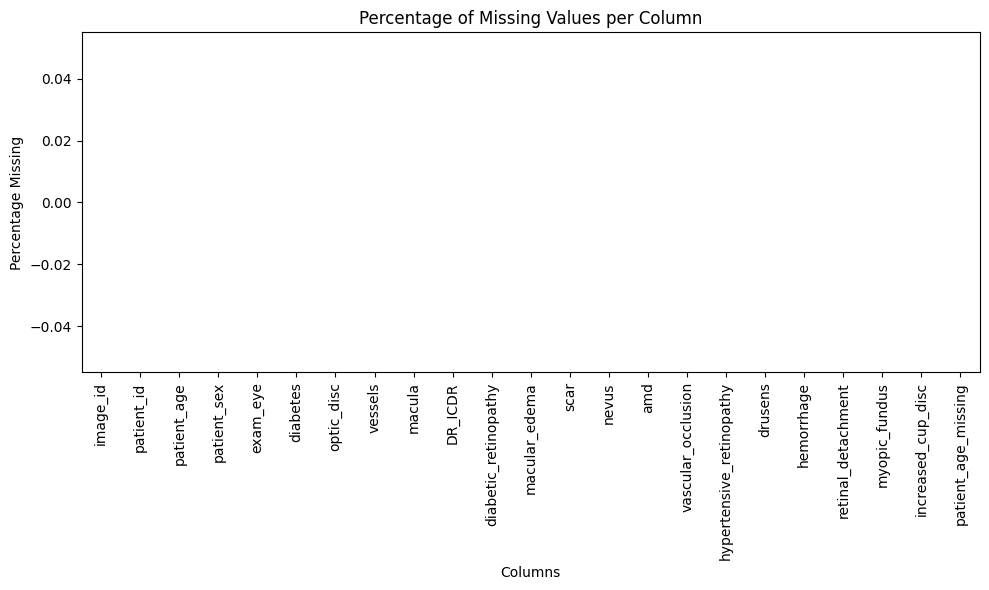

In [33]:
show_missing(data2)

In [54]:
data2_clean = data2.select_dtypes(include=['int64', 'float64'])
# data2_clean.drop(columns=['DR_ICDR'],inplace=True)

## **Model 2**